Starting 1D PIC Simulation. Steps per case: 5000
Running Te = 2.5 eV...
Running Te = 5.0 eV...
Running Te = 10.0 eV...


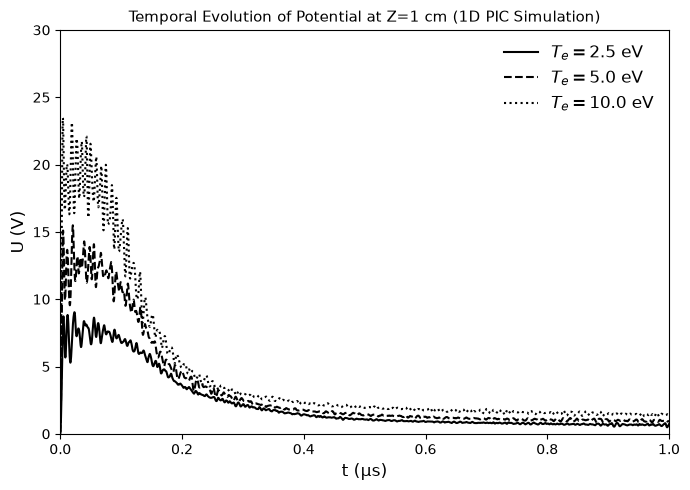

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.constants as const

"""
1D KINETIC PIC SIMULATION: TEMPORAL SHEATH EVOLUTION
----------------------------------------------------
This is a true physics simulation. It solves the Vlasov-Poisson 
system kinetically using the Particle-in-Cell (PIC) method.
"""

# --- 1. Physical Constants & Simulation Parameters ---
e = const.e
m_e = const.m_e
# PHYSICS TRICK: We use an artificial reduced ion mass (1000x electron mass).
# In a real 1 microsecond window, true Argon ions (73,000x m_e) barely move. 
# To see the sheath relaxation (the decay curve) quickly on a standard PC, 
# plasma physicists standardly reduce m_i.
m_i = 1000 * m_e  
eps0 = const.epsilon_0

L = 0.02             # 2 cm gap (Z = 1 cm is the center)
Nx = 50              # Number of spatial grid cells
dx = L / Nx          # Cell width
xg = np.linspace(0, L, Nx+1) # Grid points

n0 = 1e14            # Initial plasma density (m^-3)
Te_cases = [2.5, 5.0, 10.0]  # Initial electron temperatures (eV)
Ti = 0.025           # Ion temperature (eV) - near room temp

dt = 2e-10           # Time step (must resolve the plasma frequency)
t_max = 1e-6         # Simulate up to 1 microsecond
Nt = int(t_max / dt)
time_array = np.linspace(0, t_max, Nt) * 1e6 # in microseconds

# --- 2. Poisson Solver Setup ---
# 1D discrete Laplacian matrix for solving: d^2(phi)/dx^2 = -rho / eps0
A = sp.diags([1, -2, 1], [-1, 0, 1], shape=(Nx-1, Nx-1), dtype=float).tocsc()

def weight_to_grid(x_pos, N_total_particles, specific_weight):
    """Cloud-in-Cell (CIC) linear interpolation of particles to grid."""
    idx = np.floor(x_pos / dx).astype(int)
    frac = (x_pos / dx) - idx
    
    # Distribute charge to left and right nodes of the cell
    rho = np.bincount(idx, weights=1-frac, minlength=Nx+1) + \
          np.bincount(idx+1, weights=frac, minlength=Nx+1)
    return rho * specific_weight * e / dx

# --- 3. Main Simulation Loop ---
results = {}

print(f"Starting 1D PIC Simulation. Steps per case: {Nt}")

for Te in Te_cases:
    print(f"Running Te = {Te} eV...")
    
    # Thermal velocities
    v_te = np.sqrt(e * Te / m_e)
    v_ti = np.sqrt(e * Ti / m_i)
    
    # Initialize Super-Particles
    Np_init = 20000 
    spwt = n0 * L / Np_init # How many real particles one super-particle represents
    
    # Start with a localized plasma cloud in the center (0.5 cm to 1.5 cm)
    x_e = np.random.uniform(L/4, 3*L/4, Np_init)
    x_i = np.random.uniform(L/4, 3*L/4, Np_init)
    v_e = np.random.normal(0, v_te, Np_init)
    v_i = np.random.normal(0, v_ti, Np_init)
    
    center_potential = []

    for step in range(Nt):
        # 1. Calculate Charge Density (rho)
        rho_grid = weight_to_grid(x_i, len(x_i), spwt) - weight_to_grid(x_e, len(x_e), spwt)
        
        # 2. Solve Poisson's Equation for Potential (phi)
        # Boundaries phi(0) = phi(L) = 0 (Grounded walls)
        rhs = -rho_grid[1:-1] / eps0 * dx**2
        phi_inner = spla.spsolve(A, rhs)
        phi = np.zeros(Nx+1)
        phi[1:-1] = phi_inner
        
        # Record the potential exactly at the center (Z = 1 cm)
        center_potential.append(phi[Nx//2])
        
        # 3. Calculate Electric Field E = -d(phi)/dx
        E = np.zeros(Nx+1)
        E[1:-1] = (phi[:-2] - phi[2:]) / (2*dx)
        E[0] = (phi[0] - phi[1]) / dx
        E[-1] = (phi[-2] - phi[-1]) / dx
        
        # 4. Interpolate E-field back to particles
        idx_e = np.floor(x_e / dx).astype(int)
        frac_e = (x_e / dx) - idx_e
        E_e = E[idx_e] * (1-frac_e) + E[idx_e+1] * frac_e
        
        idx_i = np.floor(x_i / dx).astype(int)
        frac_i = (x_i / dx) - idx_i
        E_i = E[idx_i] * (1-frac_i) + E[idx_i+1] * frac_i
        
        # 5. Push Particles (Leapfrog kinematics)
        v_e += (-e / m_e) * E_e * dt
        x_e += v_e * dt
        
        v_i += (e / m_i) * E_i * dt
        x_i += v_i * dt
        
        # 6. Apply Boundary Conditions (Particles hitting the wall vanish)
        keep_e = (x_e > 0) & (x_e < L)
        x_e, v_e = x_e[keep_e], v_e[keep_e]
        
        keep_i = (x_i > 0) & (x_i < L)
        x_i, v_i = x_i[keep_i], v_i[keep_i]
        
        # 7. Source Term: Inject new electron-ion pairs at the center 
        # (simulating ionization maintaining the plasma)
        N_inject = 10 # Inject 10 pairs per timestep
        x_new = np.random.normal(L/2, 0.001, N_inject) # tightly packed at Z=1cm
        
        x_e = np.concatenate((x_e, x_new))
        v_e = np.concatenate((v_e, np.random.normal(0, v_te, N_inject)))
        
        x_i = np.concatenate((x_i, x_new))
        v_i = np.concatenate((v_i, np.random.normal(0, v_ti, N_inject)))

    results[Te] = center_potential

# --- 4. Plotting the Results ---
plt.figure(figsize=(7, 5))
line_styles = ['-', '--', ':']
for (Te, phi_data), ls in zip(results.items(), line_styles):
    plt.plot(time_array, phi_data, label=f'$T_e = {Te}$ eV', color='black', linestyle=ls)

plt.xlabel('t (µs)', fontsize=12)
plt.ylabel('U (V)', fontsize=12)
plt.title('Temporal Evolution of Potential at Z=1 cm (1D PIC Simulation)', fontsize=11)
plt.xlim(0, 1.0)
plt.ylim(0, 30)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()
# plt.savefig('sheath_temporal_evolution.png', dpi=150)
# print("Simulation complete. Plot saved as 'sheath_temporal_evolution.png'.")

In [8]:
import pandas as pd
import numpy as np

# 1. The visually extracted data from the reference plot
data = {
    "x_t (Time µs)": [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "y_t (U 2.5eV)": [7.0, 6.5, 5.5, 4.8, 4.2, 3.5, 3.0, 2.8, 2.5, 2.2, 2.0],
    "y_t (U 5eV)":   [13.5, 12.0, 10.0, 8.5, 6.5, 5.5, 5.0, 4.5, 4.2, 3.8, 3.5],
    "y_t (U 10eV)":  [26.0, 23.0, 17.0, 13.5, 10.5, 9.0, 7.5, 6.5, 6.5, 6.0, 5.5],
}

df = pd.DataFrame(data)

# 2. Add the placeholder column for time
df["x_p (Sim Time µs)"] = df["x_t (Time µs)"]

# 3. Extract and match simulation data to our 11 exact time points
for Te, phi_data in results.items():
    # Fix 1: Added the 'f' prefix so it correctly names the column "y_p (Sim 2.5eV)", etc.
    col_name = f"y_p (Sim {Te}eV)"
    
    # Fix 2: Interpolate the 5000-point simulation data down to our 11 target points
    # It looks at the 11 target times, finds where they fall in the massive 'time_array', 
    # and pulls the exact corresponding 'phi_data' potential values.
    matched_y_values = np.interp(df["x_t (Time µs)"], time_array, phi_data)
    
    df[col_name] = matched_y_values

# 4. Export to Excel
output_filename = "sheath_potential_comparison.xlsx"
df.to_excel(output_filename, index=False)

print(f"Success! Simulation data sliced and saved to {output_filename}")

Success! Simulation data sliced and saved to sheath_potential_comparison.xlsx
